In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from datasets import MNISTDataset
tf.__version__

'2.0.0'

5


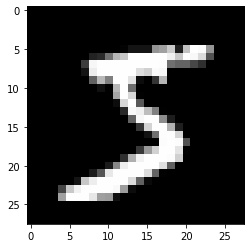

In [19]:
mnist = tf.keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print(train_labels[0])
plt.imshow(train_images[0], cmap="Greys_r")

data = MNISTDataset(train_images.reshape([-1, 784]), train_labels, 
                    test_images.reshape([-1, 784]), test_labels,
                    batch_size=128)

Im going to use random.uniform, so we need to setup the min and max values provided in the Assignment
We are using random.uniform for the weights and the biases instead of everything being 0 at the beginning.
I think this is the case because the neurons can't be activated and updated if everything is just set to zero. The input would not matter.

In [20]:
tf.random.uniform(
    shape=[], #shape without "[]" doesnt work
    minval=-0.1,
    maxval=0.1,
    dtype=tf.dtypes.float32,
    seed=None,
    name=None
)

<tf.Tensor: id=12874017, shape=(), dtype=float32, numpy=-0.084545135>

We want to have one additional layer, that is why we are going to add an additonal pair of weights and biases

In [21]:
train_steps = 1000
learning_rate = 0.1
epochs=100

### weights and bias for the connection between the input and the hidden layer ###
W1 = tf.Variable(tf.random.uniform([784, 64]), dtype=tf.float32) # For the start im going with 64 neurons in the hidden layer
b1 = tf.Variable(tf.random.uniform([64]), dtype=tf.float32)
### weights and bias for the connection between the hidden and the output layer ###
W2 = tf.Variable(tf.random.uniform([64, 10]), dtype=tf.float32)
b2 = tf.Variable(tf.random.uniform([10]), dtype=tf.float32) #10 neurons in the output layer for the 10 classes

We have to tweak the provided code a little bit, so that it takes our hidden layer into consideration

I also implemented a for loop so that our code trains for 100 epochs and then we are just going to take a look to see what happened.

Because of the new layer our model needs some more time than before to actually be good at identifying the right numbers.

In [22]:
for x in range(epochs):
    for step in range(train_steps):
        img_batch, lbl_batch = data.next_batch()
        with tf.GradientTape() as tape:
            ### input to hidden ### 
            hidden_out = tf.add(tf.matmul(img_batch, W1), b1) ### gonna change "tf.matmul(img_batch, W) + b" to tf.add(...) --> seems cleaner
            hidden_out = tf.nn.relu(hidden_out) #activation via relu
            ### hidden to output ### 
            logits = tf.add(tf.matmul(hidden_out, W2), b2) #advice from Jens: just call the very last layer logits
            xent = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(
                logits=logits, labels=lbl_batch))

        grads = tape.gradient(xent, [W1, b1, W2, b2])
        W1.assign_sub(learning_rate * grads[0])
        b1.assign_sub(learning_rate * grads[1])
        W2.assign_sub(learning_rate * grads[2])
        b2.assign_sub(learning_rate * grads[3])


        if not step % 100:
            preds = tf.argmax(logits, axis=1, output_type=tf.int32)
            acc = tf.reduce_mean(tf.cast(tf.equal(preds, lbl_batch),
                                 tf.float32))
            print("Loss: {} Accuracy: {}".format(xent, acc))

Loss: 203.47525024414062 Accuracy: 0.125
Loss: 2.2728257179260254 Accuracy: 0.1328125
Loss: 2.242823600769043 Accuracy: 0.1875
Loss: 2.302828311920166 Accuracy: 0.1171875
Loss: 2.279771327972412 Accuracy: 0.171875
Starting new epoch...
Loss: 2.2623093128204346 Accuracy: 0.1328125
Loss: 2.53469181060791 Accuracy: 0.109375
Loss: 2.280360698699951 Accuracy: 0.09375
Loss: 2.156546115875244 Accuracy: 0.1484375
Loss: 2.201723098754883 Accuracy: 0.1484375
Starting new epoch...
Loss: 2.1506149768829346 Accuracy: 0.203125
Loss: 2.1988534927368164 Accuracy: 0.15625
Loss: 2.1562161445617676 Accuracy: 0.1328125
Loss: 2.1623597145080566 Accuracy: 0.15625
Loss: 2.2252626419067383 Accuracy: 0.15625
Starting new epoch...
Loss: 2.044168472290039 Accuracy: 0.171875
Loss: 2.0217010974884033 Accuracy: 0.21875
Loss: 2.240734100341797 Accuracy: 0.2578125
Loss: 1.8537187576293945 Accuracy: 0.328125
Starting new epoch...
Loss: 1.9881219863891602 Accuracy: 0.2734375
Loss: 1.8248114585876465 Accuracy: 0.234375


In [6]:
print("Loss: {} Accuracy: {}".format(xent, acc))

Loss: 0.8365139961242676 Accuracy: 0.734375


So the result is okay, but its worse than without the hidden layer. I did this run a few times and the accuracy ends up somewehere between 70 % and 90 %.
There might be something wrong in the code itself, we would have to do some further experiments
For example we could:
    -change the initialize other values for the weights and biases
    -use less or more neurons in the hidden layer
    -use another activation function
    -change the learning rate

In [23]:
logits_1 = tf.nn.relu(tf.matmul(data.test_data, W1) + b1) 
test_preds = tf.argmax(tf.nn.softmax(tf.matmul(logits_1, W2) + b2), axis=1, output_type=tf.int32)

acc = tf.reduce_mean(tf.cast(tf.equal(test_preds, data.test_labels),
                             tf.float32))
print(acc)

tf.Tensor(0.9082, shape=(), dtype=float32)


Lets do another experiment. I'm going to use Fashion MNIST, 2 hidden layers with each 32 Neurons and a learning rate of 0.2

9


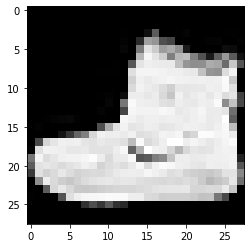

In [8]:
from datasets import MNISTDataset
mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print(train_labels[0])
plt.imshow(train_images[0], cmap="Greys_r")

data = MNISTDataset(train_images.reshape([-1, 784]), train_labels, 
                    test_images.reshape([-1, 784]), test_labels,
                    batch_size=128)

In [9]:
tf.random.uniform(
    shape=[], #shape without "[]" doesnt work
    minval=-0.1,
    maxval=0.1,
    dtype=tf.dtypes.float32,
    seed=None,
    name=None
)

<tf.Tensor: id=5407085, shape=(), dtype=float32, numpy=0.08095453>

In [10]:
train_steps = 1000
learning_rate = 0.2
epochs=100

### weights and bias for the connection between the input and the hidden layer ###
W1 = tf.Variable(tf.random.uniform([784, 32]), dtype=tf.float32) 
b1 = tf.Variable(tf.random.uniform([32]), dtype=tf.float32)
### weights and bias for the connection between hidden to hidden ###
W2 = tf.Variable(tf.random.uniform([32, 32]), dtype=tf.float32)
b2 = tf.Variable(tf.random.uniform([32]), dtype=tf.float32)
### weights and bias for the connection between the hidden and the output layer ###
W3 = tf.Variable(tf.random.uniform([32, 10]), dtype=tf.float32)
b3 = tf.Variable(tf.random.uniform([10]), dtype=tf.float32) #10 neurons in the output layer for the 10 classes

In [11]:
for x in range(epochs):
    for step in range(train_steps):
        img_batch, lbl_batch = data.next_batch()
        with tf.GradientTape() as tape:
            ### input to hidden ### 
            hidden_out = tf.add(tf.matmul(img_batch, W1), b1)
            hidden_out = tf.nn.relu(hidden_out) #activation via relu
            ### hidden to hidden ### 
            hidden2_out = tf.add(tf.matmul(hidden_out, W2), b2)
            hidden2_out = tf.nn.relu(hidden2_out) #activation via relu
            ### hidden to output ### 
            logits = tf.add(tf.matmul(hidden2_out, W3), b3) #advice from Jens: just call the very last layer logits
            xent = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(
                logits=logits, labels=lbl_batch))

        grads = tape.gradient(xent, [W1, b1, W2, b2, W3, b3])
        W1.assign_sub(learning_rate * grads[0])
        b1.assign_sub(learning_rate * grads[1])
        W2.assign_sub(learning_rate * grads[2])
        b2.assign_sub(learning_rate * grads[3])
        W3.assign_sub(learning_rate * grads[4])
        b3.assign_sub(learning_rate * grads[5])


        if not step % 100:
            preds = tf.argmax(logits, axis=1, output_type=tf.int32)
            acc = tf.reduce_mean(tf.cast(tf.equal(preds, lbl_batch),
                                 tf.float32))
            print("Loss: {} Accuracy: {}".format(xent, acc))

Loss: 3411.0498046875 Accuracy: 0.109375
Loss: 2.2967329025268555 Accuracy: 0.140625
Loss: 2.3053550720214844 Accuracy: 0.0703125
Loss: 2.301682949066162 Accuracy: 0.125
Loss: 2.301631450653076 Accuracy: 0.0859375
Starting new epoch...
Loss: 2.3031156063079834 Accuracy: 0.1015625
Loss: 2.3004837036132812 Accuracy: 0.125
Loss: 2.3020803928375244 Accuracy: 0.09375
Loss: 2.3039355278015137 Accuracy: 0.09375
Loss: 2.302426338195801 Accuracy: 0.09375
Starting new epoch...
Loss: 2.303802490234375 Accuracy: 0.09375
Loss: 2.3028297424316406 Accuracy: 0.1015625
Loss: 2.303548574447632 Accuracy: 0.0859375
Loss: 2.30464506149292 Accuracy: 0.078125
Loss: 2.3027544021606445 Accuracy: 0.1171875
Starting new epoch...
Loss: 2.3058691024780273 Accuracy: 0.0546875
Loss: 2.3016867637634277 Accuracy: 0.1015625
Loss: 2.302628755569458 Accuracy: 0.09375
Loss: 2.30438232421875 Accuracy: 0.0703125
Starting new epoch...
Loss: 2.3000621795654297 Accuracy: 0.15625
Loss: 2.300656795501709 Accuracy: 0.1015625
Loss

That did not work so well. Even after a 100 epochs our model did not really learn anything useful. 

In [12]:
print("Loss: {} Accuracy: {}".format(xent, acc))

Loss: 2.30329966545105 Accuracy: 0.1484375


Short Summary:
As we have seen by now, we can build a deep neural network with tensorflow in quite a short time, but there are some minor inconveniences, for example:
    -naming the variables (bias and weights)
    -changing the datatypes around
    -defining the number of neurons from the layer before
    -much code for doing the same tasks all over again
It seems that all in all this approach works for smaller models, but I think it would be increasingly difficult for larger models

And there are still some problems in the code itself that I could not figure out by now

Luckily there is Keras:

In [13]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

In [14]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [15]:
model.fit(x_train, y_train, epochs=5)

model.evaluate(x_test,  y_test, verbose=2)

Train on 60000 samples
Epoch 1/5
60000/60000 [==============================] - 3s 49us/sample - loss: 0.2954 - accuracy: 0.9137
Epoch 2/5
60000/60000 [==============================] - 2s 40us/sample - loss: 0.1419 - accuracy: 0.9578
Epoch 3/5
60000/60000 [==============================] - 2s 39us/sample - loss: 0.1068 - accuracy: 0.9676
Epoch 4/5
60000/60000 [==============================] - 2s 41us/sample - loss: 0.0868 - accuracy: 0.9733
Epoch 5/5
60000/60000 [==============================] - 2s 40us/sample - loss: 0.0721 - accuracy: 0.9774
10000/1 - 0s - loss: 0.0430 - accuracy: 0.9753


[0.08267811379076448, 0.9753]

In [16]:
mnist = tf.keras.datasets.fashion_mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

In [17]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [18]:
model.fit(x_train, y_train, epochs=5)

model.evaluate(x_test,  y_test, verbose=2)

Train on 60000 samples
Epoch 1/5
60000/60000 [==============================] - 3s 44us/sample - loss: 0.5271 - accuracy: 0.8136
Epoch 2/5
60000/60000 [==============================] - 2s 39us/sample - loss: 0.4005 - accuracy: 0.8551
Epoch 3/5
60000/60000 [==============================] - 2s 39us/sample - loss: 0.3673 - accuracy: 0.8667
Epoch 4/5
60000/60000 [==============================] - 2s 39us/sample - loss: 0.3442 - accuracy: 0.8736
Epoch 5/5
60000/60000 [==============================] - 3s 42us/sample - loss: 0.3300 - accuracy: 0.8787
10000/1 - 0s - loss: 0.2911 - accuracy: 0.8706


[0.36028224210739135, 0.8706]

These experiments with keras pretty much confirm that there is something wrong with the code itself in the first experiments.
With Keras it only takes a really short time period to get a decent model. 